# 05b_Analyze — Black-Litterman 실험 결과 분석

본 노트북은 `results/*.pkl` 백테스트 결과 분석 단일 진입점.

## 노트북 섹션 구성

| § | 내용 |
|---|---|
| §0 | 환경 설정 — pkl + rf + SPY 데이터 로드 |
| §1 | K_CUT (2023-12-31 cutoff) ★ MANDATORY ★ — 모든 후속 분석에 cut 적용 |
| §2 | 거래비용 분석 — 슬롯별 turnover & TC |
| §3 | 슬롯별 마진 효과 (Sortino) — mt/rt 는 §1 에서 빌드됨 |
| §4 | 레짐 안정성 분석 ⭐ |
|  §4.1 | 비교군 (SPY + baseline) 레짐별 상세 표 |
|  §4.2 | Sortino IR Top 20 통합 대시보드 (히트맵) |
|  §4.3 | Sortino IR Top 20 전체기간 메트릭 표 |
| §5 | Winner Q-value 민감도 (winner = sortino_ir ≥ 10 + sortino 1위, 자동 식별) |
|  §5.1 | Winner 식별 + bl_runner 환경 셋업 |
|  §5.2 | Q-value sweep |
|  §5.3 | Q sensitivity 시각화 |
|  §5.4 | Q sensitivity 통계 검정 (Jobson-Korkie + Block Bootstrap) |
| §6 | Winner PCT_GROUP 민감도 |
|  §6.1 | PCT_GROUP sweep |
|  §6.2 | PCT sensitivity 시각화 |
|  §6.3 | PCT sensitivity 통계 검정 |

**필터 정책** — `mt`/`rt` (§3·§4 일반 슬롯 분석) 는 sensitivity sweep 변형 자동 제외.

**TC 정책** — §1 에서 `ACTIVE_TC = 0.002` (20bp/side) 로 재계산. pkl 자체도 이미 20bp baked-in.

---

**관련 가이드**:
- [PROJECT_OVERVIEW.md](PROJECT_OVERVIEW.md) (전체 파이프라인)
- [SENSITIVITY_ANALYSIS.md](SENSITIVITY_ANALYSIS.md) — §5·§6 민감도 해석 가이드

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '05b_Analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['mat_mcap_mcap_fix_he']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["mat_mcap_mcap_fix_he"]["ret"].index[0].date()} ~ {loaded["mat_mcap_mcap_fix_he"]["ret"].index[-1].date()}')


로드 완료: 90개 실험
기간: 2010-01-31 ~ 2025-12-31


## §1. K_CUT (2023-12-31 cutoff) 적용 (모든 후속 분석에 mandatory)

기존 백테스트 결과(`results/*.pkl`)는 2010-01 ~ 2025-12 (192개월). **본 셀을 데이터 로드 직후 가장 먼저 실행**해서 모든 ret/spy_ret/comp을 **2023-12-31까지로 truncate** 한 임시 pkl을 `outputs/05b_analyze/_cut_pkl/`에 저장하고, `RESULTS_DIR`를 그쪽으로 재지정.

**왜 mandatory인가** — Look-ahead bias 방지:
- 2024-2025를 Phase 2 holdout으로 사용할 예정 → **선정 단계(2010-2023)에 holdout 데이터 leak 금지**
- 셀 5 turnover (I1), J1/J2 슬롯 효과, K1·K2·K2-T 레짐 분석 등 **모든 후속 셀이 자동으로 컷 적용된 mt/rt/loaded 사용**
- 예외 1개: `_ORIG_RESULTS_DIR`는 보존 — Phase 2 단계에서 winner 슬롯의 2024-2025 데이터 로드용

**효과 범위** (이 셀 실행 후 노트북 전체):
- `loaded[name]['ret']/['spy_ret']/['comp']` 모두 ≤ 2023-12-31
- `RESULTS_DIR = outputs/05b_analyze/_cut_pkl/`
- `mt`, `rt`, `rt_sm`이 cut 기준으로 사전 빌드됨 (J1/K1에서 다시 빌드해도 동일)
- 기준 슬롯 `baseline_ret` (= `mat_mcap_mcap_fix_he`) 도 cut

> ⚠️ 컷 해제하려면 노트북 처음부터 다시 실행. 본 셀을 SKIP하면 leakage 위험 ⚠️


In [2]:
# ── §1. 2023-12-31 cutoff (MANDATORY, 데이터 로드 직후 실행) ─────────
# 모든 ret/comp을 CUTOFF까지 truncate한 임시 pkl 디렉토리 생성 후
# RESULTS_DIR + loaded를 그쪽으로 재지정 → 후속 모든 셀이 cut 기준으로 작동.
# Look-ahead bias 방지: 2024-2025는 Phase 2 holdout이므로 선정 분석에서 제외 필수.
#
# ⭐ ACTIVE_TC: 분석에 적용할 거래비용 (편측, per-side). pkl에 baked-in된 net ret 대신
#    ret = gross_ret - turnover × ACTIVE_TC 로 on-the-fly 재계산.
#    pkl 자체는 손 안 댐 → 시나리오 비교 시 ACTIVE_TC 변수만 바꾸면 자유롭게 전환.
import pickle, shutil
from master_table import build_master_table, build_regime_table, REGIMES, PERIODS_DEFAULT

CUTOFF     = pd.Timestamp('2023-12-31')
ACTIVE_TC  = 0.002   # 20bp/side  (pkl 도 20bp baked-in 이라 동일 시 redundant; 다른 값 비교 시 활용)
print(f'■ Cutoff 적용: ret series를 {CUTOFF.date()} 까지로 truncate')
print(f'■ ACTIVE_TC = {ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp/side, two-way: turnover × {ACTIVE_TC} per month)')

CUT_DIR = OUT_DIR / '_cut_pkl'
if CUT_DIR.exists():
    shutil.rmtree(CUT_DIR)
CUT_DIR.mkdir(parents=True, exist_ok=True)

# 원본 RESULTS_DIR (cell 1에서 정의된 results/) 보존
_ORIG_RESULTS_DIR = Path.cwd() / 'results'

def _apply_tc_recompute(res, active_tc):
    """pkl 결과 dict에서 ret = gross_ret - turnover × active_tc 로 재계산.
    gross_ret 또는 turnover 누락 시 기존 ret 그대로 둠 (안전 fallback)."""
    gross = res.get('gross_ret')
    comp  = res.get('comp')
    if not isinstance(gross, pd.Series) or len(gross) == 0:
        return  # 옛 pkl 호환 — 변경 없음
    if not isinstance(comp, pd.DataFrame) or 'turnover' not in comp.columns:
        return
    if 'date' in comp.columns:
        turn = pd.Series(comp['turnover'].values, index=pd.to_datetime(comp['date']))
    elif isinstance(comp.index, pd.DatetimeIndex):
        turn = comp['turnover']
    else:
        return
    turn = turn.reindex(gross.index).fillna(0)
    res['ret'] = gross - turn * active_tc
    if 'tc_cost' in comp.columns:
        comp['tc_cost'] = comp['turnover'] * active_tc

# 모든 pkl을 cutoff까지 잘라 + ACTIVE_TC 적용 후 저장
n_written = 0
for pkl in sorted(_ORIG_RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        res = pickle.load(f)
    # 1) cutoff truncate
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    # 2) ACTIVE_TC 재계산 (gross_ret 보존, ret만 갱신)
    _apply_tc_recompute(res, ACTIVE_TC)
    with open(CUT_DIR / pkl.name, 'wb') as f:
        pickle.dump(res, f)
    n_written += 1
print(f'  → {n_written}개 pkl을 {CUT_DIR.relative_to(Path.cwd())} 에 저장 (ACTIVE_TC={ACTIVE_TC})')

# RESULTS_DIR 재지정 → 이후 모든 build_*_table / pkl 로드가 cut 사용
RESULTS_DIR = CUT_DIR

# spy_ret, baseline_ret cut 버전으로 교체
spy_ret = spy_ret[spy_ret.index <= CUTOFF]

def _load_ret_cut(name):
    with open(CUT_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret     = _load_ret_cut('mat_mcap_mcap_fix_he')

# loaded 딕셔너리도 동일하게 cut + ACTIVE_TC 재계산 (이후 셀들이 직접 접근)
for name, res in loaded.items():
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    _apply_tc_recompute(res, ACTIVE_TC)

# mt/rt 재빌드
SENS_FILTER = lambda s: ~s.str.endswith(('_q55','_q64','_q70')) & ~s.str.startswith('winner_')
mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
mt = mt_full[SENS_FILTER(mt_full['name'])].copy()
rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
rt = rt_full[SENS_FILTER(rt_full['name'])].copy()

rt_sm = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
                 on='name', how='left')

print(f'\n■ Cutoff + TC 적용 후:')
print(f'  baseline.ret 기간: {baseline_ret.index[0].date()} ~ {baseline_ret.index[-1].date()} ({len(baseline_ret)}개월)')
print(f'  spy_ret 기간     : {spy_ret.index[0].date()} ~ {spy_ret.index[-1].date()} ({len(spy_ret)}개월)')
print(f'  mt: {len(mt)}개 실험 × {mt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'  rt: {len(rt)}개 실험 × {rt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'\n→ 후속 모든 셀이 cutoff + ACTIVE_TC={ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp) 기준으로 작동')
print(f'   pkl 원본은 results/ 그대로, 후처리는 ACTIVE_TC만 바꾸면 자유 전환')


■ Cutoff 적용: ret series를 2023-12-31 까지로 truncate
■ ACTIVE_TC = 0.002 (20bp/side, two-way: turnover × 0.002 per month)
  → 90개 pkl을 outputs/05b_Analyze/_cut_pkl 에 저장 (ACTIVE_TC=0.002)

■ Cutoff + TC 적용 후:
  baseline.ret 기간: 2010-01-31 ~ 2023-12-31 (168개월)
  spy_ret 기간     : 2010-01-31 ~ 2023-12-31 (168개월)
  mt: 90개 실험 × 43컬럼  (sensitivity 변형 제외)
  rt: 90개 실험 × 56컬럼  (sensitivity 변형 제외)

→ 후속 모든 셀이 cutoff + ACTIVE_TC=0.002 (20bp) 기준으로 작동
   pkl 원본은 results/ 그대로, 후처리는 ACTIVE_TC만 바꾸면 자유 전환


## §2. 거래비용 분석 (Turnover & TC)

### TC (Transaction Cost, 거래비용)이란?
매 리밸런싱마다 실제로 발생하는 손실 = **수수료 + 슬리피지 + bid-ask spread**.

본 백테스트 가정:
- **TC_RATE = 0.002 (20bp = 0.2%)** — **편측(per-side) 거래비용** (매수 한 번 또는 매도 한 번당)
- **turnover는 two-way Σ|Δw| ∈ [0, 2]** — 매수+매도를 모두 카운트 (완전 교체 시 2.0)
- 따라서 `turnover × TC_RATE`만으로 매수·매도 양쪽 비용이 자동 반영됨
- 매월 리밸런싱 → 연간 TC = `평균 turnover × 0.002 × 12`

> ⚠️ 옛 표현 "편도 turnover 기준"은 부정확. 정확히는 "**편측 tc × two-way turnover**".

### 무엇을 보나
매트릭스 90개라 개별 비교는 어려움. **슬롯별 집계**로 패턴 파악:
- 어느 슬롯이 turnover ↑ → TC ↑ → 실수익 잠식
- 슬롯 차이가 커야 의미 있음 (모든 슬롯이 비슷하면 모델 차이 없음)


90개 매트릭스 슬롯
전체 평균 turnover: 0.608
전체 평균 연간 TC: 1.46%


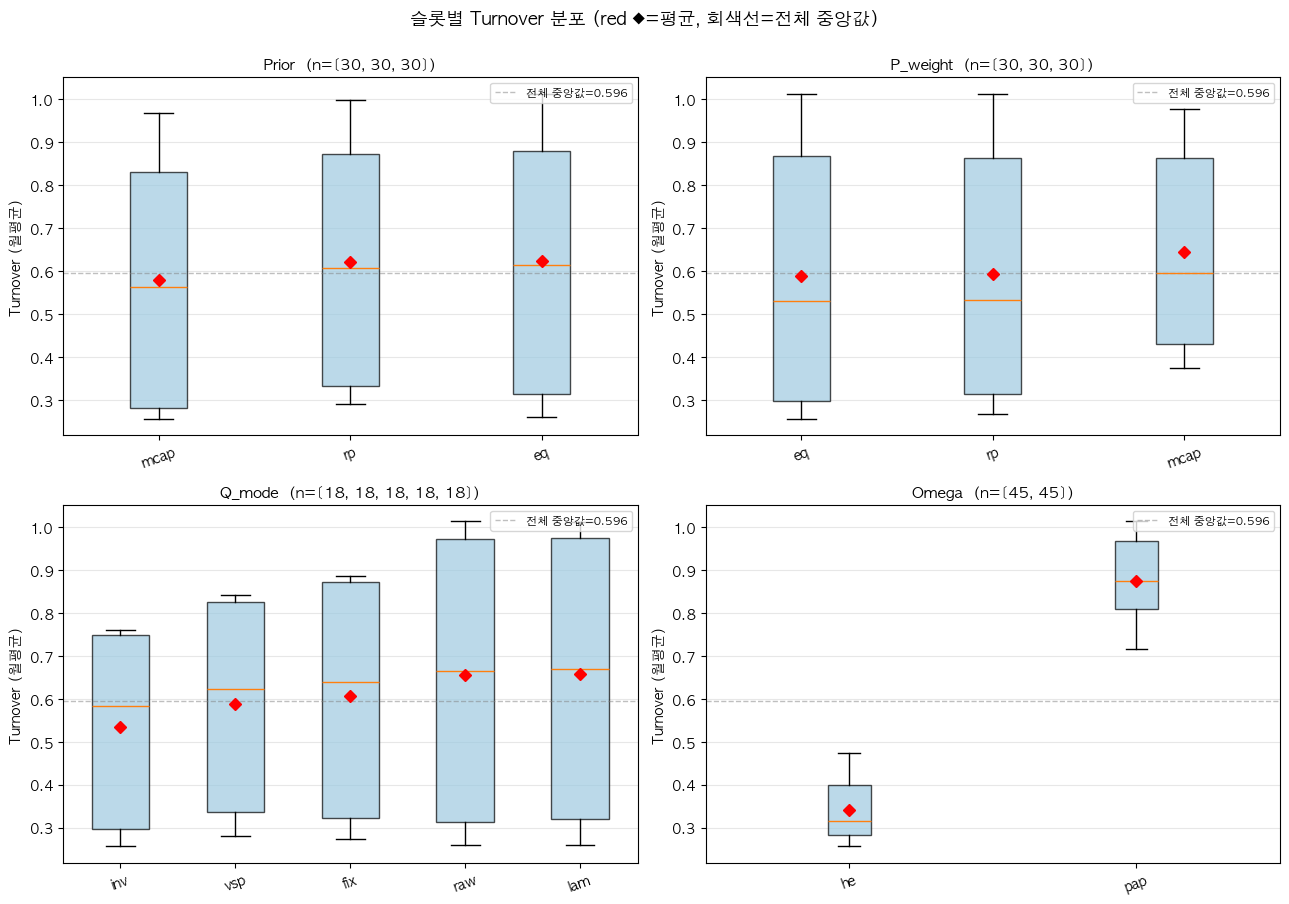

In [3]:
# ── §2.1 슬롯별 Turnover boxplot ────────────────────────────
# TC = Transaction Cost (거래비용) = 수수료 + 슬리피지 + bid-ask spread
# TC_RATE = 0.002 (20bp), 매월 리밸런싱 → 연간 TC = avg_turnover × 0.002 × 12

from master_table import parse_config

TC_RATE = 0.002

# DataFrame 빌드 — 모든 실험의 슬롯 + turnover
rows = []
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    cfg = res.get('config', {})
    meta = parse_config(cfg) if cfg else {}
    to_mean = float(comp['turnover'].mean())
    rows.append({
        'name'      : name,
        'canonical' : meta.get('canonical', name),
        'prior_s'   : meta.get('prior_s'),
        'pw_s'      : meta.get('pw_s'),
        'q_s'       : meta.get('q_s'),
        'om_s'      : meta.get('om_s'),
        'turnover'  : to_mean,
        'tc_annual' : to_mean * TC_RATE * 12,
    })
df_to = pd.DataFrame(rows)
print(f'{len(df_to)}개 매트릭스 슬롯')
print(f'전체 평균 turnover: {df_to["turnover"].mean():.3f}')
print(f'전체 평균 연간 TC: {df_to["tc_annual"].mean()*100:.2f}%')

# ── 슬롯별 Turnover 분포 boxplot (4 패널 — p_mode 는 ls 단일이라 제외) ──
slot_info = [('prior_s','Prior'), ('pw_s','P_weight'), ('q_s','Q_mode'), ('om_s','Omega')]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (slot, label) in enumerate(slot_info):
    ax = axes[i]
    order = df_to.groupby(slot)['turnover'].mean().sort_values().index.tolist()
    data  = [df_to[df_to[slot]==k]['turnover'].values for k in order]
    counts = [len(d) for d in data]
    bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6))
    for patch in bp['boxes']:
        patch.set_facecolor('#9ecae1'); patch.set_alpha(0.7)
    ax.set_title(f'{label}  (n={counts})', fontsize=11)
    ax.set_ylabel('Turnover (월평균)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    overall = df_to['turnover'].median()
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.5, lw=1,
               label=f'전체 중앙값={overall:.3f}')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('슬롯별 Turnover 분포 (red ◆=평균, 회색선=전체 중앙값)', fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / 'turnover_by_slot.png', dpi=120, bbox_inches='tight')
plt.show()


## §3. 슬롯별 마진 효과 (Sortino)

`mt`/`rt` 는 K_CUT 셀에서 사전 빌드됨. 본 섹션은 어느 슬롯값이 평균적으로 sortino 가 큰지 시각적으로 확인.


■ §3.1 슬롯별 Sortino 분포

=== 슬롯별 mean Sortino (높은 순) ===

[prior_s]
         count   mean  median    std    min    max
prior_s                                           
rp          30  1.598   1.612  0.172  1.300  1.884
eq          30  1.593   1.611  0.183  1.288  1.905
mcap        30  1.576   1.562  0.128  1.365  1.825

[pw_s]
      count   mean  median    std    min    max
pw_s                                           
eq       30  1.640   1.682  0.139  1.355  1.826
rp       30  1.604   1.619  0.140  1.340  1.822
mcap     30  1.522   1.445  0.183  1.288  1.905

[q_s]
     count   mean  median    std    min    max
q_s                                           
raw     18  1.766   1.776  0.082  1.587  1.905
lam     18  1.711   1.726  0.106  1.488  1.850
fix     18  1.540   1.532  0.092  1.424  1.711
vsp     18  1.502   1.458  0.105  1.389  1.710
inv     18  1.424   1.380  0.102  1.288  1.606

[om_s]
      count   mean  median    std    min    max
om_s                                   

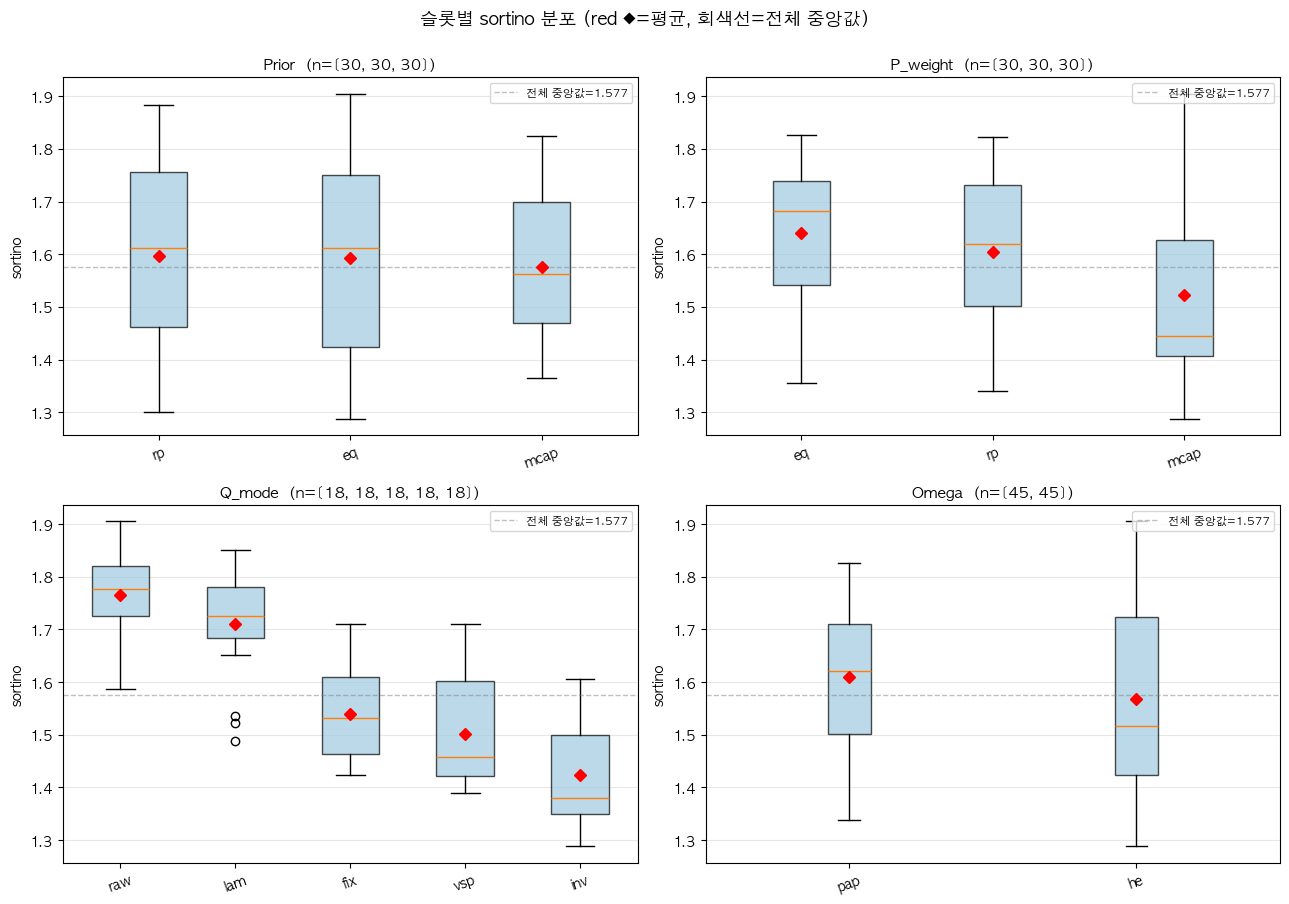

In [4]:
# ── §3.1 슬롯별 marginal effect — Sortino 분포 ────
# 어느 슬롯이 sortino에 큰 영향? prior_s, pw_s, q_s, om_s (p_s = 'ls' 단일이라 제외)
# Sortino = 하방 변동성 기반 위험조정 수익 → 저위험 anomaly 컨셉에 더 적합

from master_table import slot_summary
from analyze_plots import plot_marginal_effects

SLOTS_J2 = ['prior_s', 'pw_s', 'q_s', 'om_s']

print('■ §3.1 슬롯별 Sortino 분포')
_ = plot_marginal_effects(mt, metric='sortino', slots=SLOTS_J2,
                          save_path=OUT_DIR / 'J2_marginal_sortino.png')

print('\n=== 슬롯별 mean Sortino (높은 순) ===')
for slot in SLOTS_J2:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sortino'))


## §4. 레짐 안정성 분석 — Sortino + 3-레짐 변동성 ⭐

### 왜 이 분석이 필요한가
- **Sharpe보다 Sortino가 본 프로젝트에 더 적합**: 저위험 anomaly 컨셉 → 하방 변동성만이 진짜 손실 위험
- **레짐별 일관성**: 한 시기만 강한 후보는 운. 모든 레짐에서 일관되게 좋은 후보를 찾아야 함
- **MDD 안정성**: 위기 레짐에서 MDD 폭증하는 후보 제외

### 3-레짐 정의 (HMM n=3 구조전환점 기반)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---:|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2024-12 (K_CUT 시 2023-12, 48m) | 60 | COVID + 22 베어 + AI 랠리 |

### 핵심 지표 (build_regime_table 출력)
- `sortino_R1..R3`: 레짐별 Sortino
- `sortino_mean`: 3 레짐 평균
- `sortino_std`: 3 레짐 표준편차 (**낮을수록 안정**)
- `sortino_ir = sortino_mean / sortino_std`: 변동 대비 평균 (메인 정렬 키)
- `sharpe_ir = sharpe_mean / sharpe_std`: Sharpe 버전 IR
- `mdd_worst`: 3 레짐 중 가장 깊은 MDD


In [5]:
# ── §4.1 비교군 (SPY + baseline) 레짐별 상세 표 ────────────
# rt / mt 는 K_CUT 셀에서 이미 빌드됨. 여기서는 baseline_ret 만 로드해서 비교군 표 출력.
import pickle, numpy as np
from master_table import regime_metrics, REGIMES

def _load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret = _load_ret('mat_mcap_mcap_fix_he')

# ── 비교군 (SPY + 표준 BL) 3-레짐 종합 메트릭 ────────────────
def _calc_ref(label, ret_series, rf, regimes):
    sortinos, mdds = [], []
    rec = {'canonical': label}
    for lbl, s, e in regimes:
        m = regime_metrics(ret_series, rf, s, e)
        if not np.isnan(m['sortino']): sortinos.append(m['sortino'])
        mdds.append(m['mdd'])
    rec['sortino_mean'] = round(np.mean(sortinos), 3) if sortinos else np.nan
    rec['sortino_std']  = round(np.std(sortinos),  3) if sortinos else np.nan
    rec['mdd_worst']    = round(np.min(mdds),      3) if mdds else np.nan
    return rec

ref_rows = [
    _calc_ref('SPY (시장 패시브)',              spy_ret,      rf, REGIMES),
    _calc_ref('mat_mcap_mcap_fix_he (표준 BL)', baseline_ret, rf, REGIMES),
]

print('■ 비교군 — 3-레짐 종합 (Sortino mean/std + MDD worst)')
display(pd.DataFrame(ref_rows).round(3))

# ── 비교군 레짐별 상세 (Sortino / Sharpe / MDD) ─────────────────
benchmarks_list = [('SPY', spy_ret), ('mat_mcap_mcap_fix_he', baseline_ret)]

print('\n■ 비교군 레짐별 상세 — Sortino / Sharpe / MDD')

for metric_key, metric_label in [('sortino','Sortino'), ('sharpe','Sharpe'), ('mdd','MDD')]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for name, ret in benchmarks_list:
        rec = {'benchmark': name}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('benchmark')
    if metric_key == 'mdd':
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))


■ 비교군 — 3-레짐 종합 (Sortino mean/std + MDD worst)


,canonical,sortino_mean,sortino_std,mdd_worst
0,SPY (시장 패시브),1.374,0.249,-0.239
1,mat_mcap_mcap_fix_he (표준 BL),1.482,0.258,-0.125



■ 비교군 레짐별 상세 — Sortino / Sharpe / MDD

[ Sortino per 레짐 ]


,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,1.407,1.661,1.053
mat_mcap_mcap_fix_he,1.753,1.556,1.135



[ Sharpe per 레짐 ]


,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,0.807,1.227,0.604
mat_mcap_mcap_fix_he,1.123,1.215,0.569



[ MDD per 레짐 ]


,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,-16.22%,-13.53%,-23.93%
mat_mcap_mcap_fix_he,-9.77%,-8.92%,-12.46%


## §4.2 Sortino IR Top 20 — 전체기간 메트릭 표

발표·보고용 단일 수치 정리 + Winner 자동 식별.

- **메트릭**: Sharpe / Sortino / Sortino_IR / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)
- **Winner 식별 기준**: `sortino_ir ≥ 10.0` 필터 (3-레짐 안정성 robust) → 그 중 전체기간 sortino 1위
- 표 안에 `sortino_ir ≥ 10` 통과 구간 (Top 13) 구분선 + winner 행에 ⭐ 마커


In [6]:
# ── §4.2 Sortino IR Top 20 — 전체기간 메트릭 표 ───────────────────
# 표시 메트릭: 순위 / 실험명 / Sharpe / Sortino / Sortino_IR / CAGR / Vol / MDD / Beta / Alpha
# Sortino_IR (= sortino_mean / sortino_std, rt에서 가져옴): 3 레짐 안정성 지표
# ⭐ 마커 = 자동 식별 winner: sortino_ir ≥ 10 필터 → 전체기간 sortino 1위
# cutoff 구분선 = sortino_ir ≥ 10 통과 후보 (Top n_stable) 와 그 이하 분리

# Winner ID — master_table.identify_winner() single source (DRY)
import importlib, master_table
importlib.reload(master_table)
from master_table import identify_winner
_w = identify_winner(mt, rt, ir_threshold=10.0, sortino_key='sortino')
WINNER_NAME, N_STABLE, WINNER_IR_THRESHOLD = _w['name'], _w['n_stable'], _w['threshold']
print(f'★ Winner (자동 식별, sortino_ir ≥ {WINNER_IR_THRESHOLD} → 전체기간 sortino 1위): {WINNER_NAME}')
print(f'  sortino_ir ≥ {WINNER_IR_THRESHOLD} 통과: {N_STABLE}개 (Top {N_STABLE})')

top20_names = rt.nlargest(20, 'sortino_ir')['name'].tolist()
summary = mt[mt['name'].isin(top20_names)].copy()
summary = summary.merge(rt[['name', 'sortino_ir']], on='name', how='left')
summary['_order'] = summary['name'].map({n: i for i, n in enumerate(top20_names)})
summary = summary.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 110
sep    = '-' * 110
print(header)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (순위 + winner 마커 + cutoff 구분선)
for i, (_, r) in enumerate(summary.iterrows(), start=1):
    canonical = str(r['canonical'])
    is_winner = r['name'] == WINNER_NAME
    rank_s   = f'{i:>2}.'
    marker   = ' ⭐' if is_winner else '  '
    name_w   = 30 if is_winner else 32
    name     = canonical[:name_w]
    name_f   = f'{name}{marker}' if is_winner else f'{name}'
    sh       = f'{r["sharpe"]:.3f}'
    so       = f'{r["sortino"]:.3f}'
    sir      = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr     = f'{r["cagr"]*100:.2f}%'
    vol      = f'{r["vol"]*100:.2f}%'
    mdd      = f'{r["mdd"]*100:.2f}%'
    beta     = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha    = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{rank_s:>3}  {name_f:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
    # cutoff 구분선: rank N_STABLE 행 직후
    if i == N_STABLE:
        print(f'{"─"*45} sortino_ir ≥ {WINNER_IR_THRESHOLD} cutoff (Top {N_STABLE}) {"─"*32}')

print(header)

# 비교군
print('\n■ 비교군 — 전체기간')
print(sep)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['mat_mcap_mcap_fix_he']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_v = rt_r['sortino_ir'].iloc[0] if len(rt_r)>0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    sir   = f'{sir_v:.2f}' if sir_v is not None else '-'
    beta  = f'{r["beta"]:.3f}' if pd.notna(r['beta']) else '-'
    alpha = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{"":>3}  {nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}{sir:>11}{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%{beta:>8}{alpha:>8}')

# SPY
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2T
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2T:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"":>3}  {"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


★ Winner (자동 식별, sortino_ir ≥ 10.0 → 전체기간 sortino 1위): mat_eq_eq_raw_pap
  sortino_ir ≥ 10.0 통과: 13개 (Top 13)
  #  실험명                               Sharpe  Sortino Sortino_IR    CAGR     변동성      MDD    Beta   Alpha
--------------------------------------------------------------------------------------------------------------
 1.  mcap_ls_rp_lam_pap                 1.070    1.705      57.17  15.13%  13.19%  -14.03%   0.733   4.70%
 2.  mcap_ls_eq_lam_pap                 1.106    1.742      39.42  15.73%  13.25%  -14.73%   0.734   5.22%
 3.  eq_ls_rp_lam_pap                   1.067    1.753      34.65  15.80%  13.86%  -13.87%   0.752   5.14%
 4.  eq_ls_rp_raw_pap                   1.069    1.777      29.85  15.69%  13.73%  -13.87%   0.737   5.21%
 5.  mcap_ls_rp_raw_pap                 1.064    1.736      22.01  14.90%  13.07%  -14.03%   0.718   4.67%
 6.  mcap_ls_eq_raw_pap                 1.099    1.775      17.70  15.52%  13.15%  -14.73%   0.724   5.15%
 7.  eq_ls_eq_raw_pap ⭐       

## §4.3 Sortino IR Top 20 통합 대시보드 (히트맵)

§4.2 표에서 식별한 winner 와 sortino_ir ≥ 10 cutoff 를 시각적으로 확인.

- 좌:SORTINO / 가운데:SHARPE / 우:MDD — 3 metric × 3 레짐 격자
- **y축 ⭐**: 자동 식별 winner 행
- **검정 점선**: rank N_STABLE (sortino_ir ≥ 10 통과 cutoff) — 그 위쪽 후보가 robust 식별 풀


■ 레짐별 Sortino — 비교군
레짐               SPY   mat_mcap_mcap_fix_he
--------------------------------------------
R1_회복           1.41                   1.75
R2_확장           1.66                   1.56
R3_변동           1.05                   1.14


=== §4.3 Sortino IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨
  → ⭐ winner (mat_eq_eq_raw_pap) · 점선 = sortino_ir ≥ 10.0 cutoff (Top 13)

■ §4.3 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_std,mdd_worst,sharpe
1,mcap_ls_rp_lam_pap,57.17,1.715,0.030,-0.140,1.070
2,mcap_ls_eq_lam_pap,39.42,1.774,0.045,-0.147,1.106
3,eq_ls_rp_lam_pap,34.65,1.802,0.052,-0.139,1.067
4,eq_ls_rp_raw_pap,29.85,1.851,0.062,-0.139,1.069
5,mcap_ls_rp_raw_pap,22.01,1.761,0.080,-0.140,1.064
6,mcap_ls_eq_raw_pap,17.70,1.823,0.103,-0.147,1.099
7,eq_ls_eq_raw_pap,16.50,1.963,0.119,-0.136,1.096
8,eq_ls_eq_lam_pap,15.98,1.918,0.120,-0.136,1.102
9,mcap_ls_rp_vsp_pap,13.57,1.628,0.120,-0.140,1.014
10,mcap_ls_eq_vsp_pap,13.03,1.694,0.130,-0.137,1.059


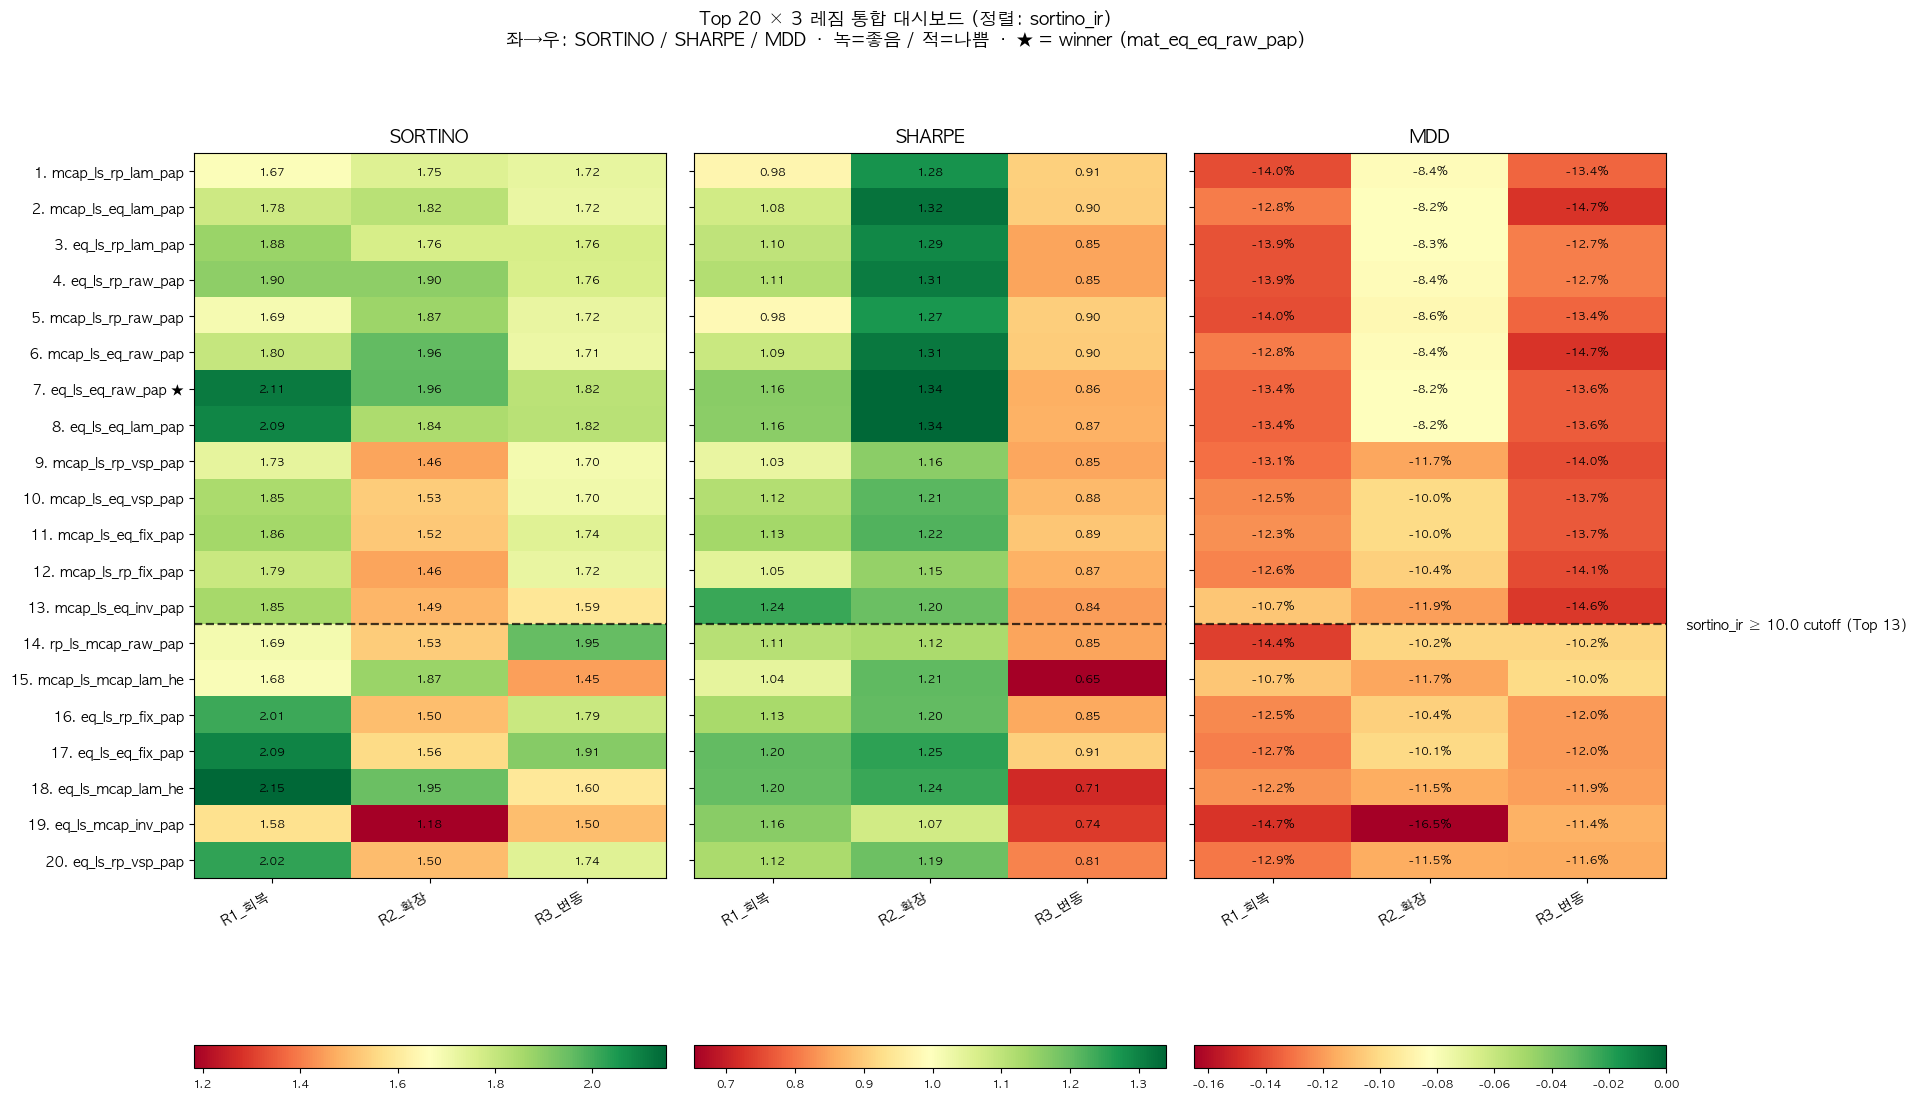

In [7]:
# ── §4.3 Sortino IR Top 20 통합 대시보드 ───────────────────────────
# §4.2 에서 정의된 WINNER_NAME / N_STABLE 재사용 → y축 ⭐ + cutoff 가로 점선
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# rt 는 §4.1 / §4.2 에서 이미 빌드됨. 본 셀에서 한 번 더 빌드 (안전망 — 단독 실행 대비).
from master_table import build_regime_table, REGIMES
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES)

# 비교군 레짐별 Sortino
print('■ 레짐별 Sortino — 비교군')
print(f'{"레짐":<12} {"SPY":>7} {"mat_mcap_mcap_fix_he":>22}')
print('-' * 44)
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,      rf, s, e)['sortino']
    bm = regime_metrics(baseline_ret, rf, s, e)['sortino']
    print(f'{lbl:<12} {sm:>7.2f} {bm:>22.2f}')

# ── §4.3 Sortino IR Top 20 — 3 metric × 3 레짐 통합 대시보드 (PNG) ─
print('\n\n=== §4.3 Sortino IR 정렬 Top 20 대시보드 ===')
print(f'  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')
print(f'  → ⭐ winner ({WINNER_NAME}) · 점선 = sortino_ir ≥ {WINNER_IR_THRESHOLD} cutoff (Top {N_STABLE})')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    save_path=OUT_DIR / 'K2A_sortino_ir_dashboard.png',
    winner_name=WINNER_NAME,
    threshold_rank=N_STABLE,
    threshold_label=f'sortino_ir ≥ {WINNER_IR_THRESHOLD} cutoff (Top {N_STABLE})',
)

# 행 매핑 표 (참고)
top20 = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20.index += 1
print('\n■ §4.3 행 매핑 (sortino_ir 큰 순)')
display(top20[['canonical','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))


## §5. Winner Q-value 민감도 (in-code, pkl 없이)

**목적**: 90 매트릭스 슬롯 중 winner 식별 → 그 winner 의 `q_value` 와 `pct_group` 민감도를 in-notebook 으로 sweep.

**왜 in-code?** 02b 의 임계값 민감도와 동일 패턴.
- pkl 영구화 불필요 (winner 가 바뀌면 자동 재계산)
- `bl_runner.walk_forward()` 가 `monthly_cache` 를 재사용 → 슬롯당 약 30초~1분
- 17개 sweep 슬롯 = 약 10~15분

**선행 조건**:
- 04_BL_Walkforward 가 90 매트릭스 pkl 생성 완료
- 본 노트북에서 mt_full, rt_full 이미 빌드됨


In [8]:
# ── §5.1 Winner 식별 + bl_runner 환경 셋업 ────────────────────────
# Winner 기준 (자동 식별, 하드코딩 없음):
#   1) sortino_ir ≥ 10 절대 임계 필터 (3-레짐 안정성 robust)
#   2) 그 중 전체기간 sortino 최댓값 (168개월 통합 위험조정 수익)
# → 임계 10 은 sortino_ir 평균(7.3)·중앙값(4.5) 보다 엄격, 상위 ~15% 컷.
#   Top-N 컷오프와 달리 절대 기준이라 슬롯 분포 변화에 robust.
from bl_runner import load_lstm_pred, build_monthly_cache, walk_forward
from bl_config import EXPERIMENTS, BASELINE

# (a) Winner 자동 식별 — master_table.identify_winner() single source (DRY)
import importlib, master_table
importlib.reload(master_table)
from master_table import identify_winner
_w = identify_winner(mt_full, rt_full, ir_threshold=10.0, sortino_key='sortino')
if _w['n_stable'] == 0:
    raise RuntimeError(f"sortino_ir ≥ {_w['threshold']} 통과 슬롯 없음 — 임계 낮춰서 재시도 필요")
winner_name = _w['name']
WINNER_IR_THRESHOLD = _w['threshold']
print(f"■ Winner 기준: sortino_ir ≥ {_w['threshold']} 필터 ({_w['n_stable']}/90 통과) → 전체기간 sortino 1위")
winner_cfg  = next((c for c in EXPERIMENTS if c['name'] == winner_name), None)
if winner_cfg is None:
    raise ValueError(f'winner {winner_name} 가 EXPERIMENTS 에 없음 — bl_config.py 확인')

print(f'★ Winner (sortino_ir 1위): {winner_name}')
print(f'  config: prior={winner_cfg["prior"]}, p_weight={winner_cfg["p_weight"]}, '
      f'q={winner_cfg["q_mode"]}, omega={winner_cfg["omega_mode"]}, '
      f'q_value={winner_cfg.get("q_value", 0.003)}')

# (b) BL 환경 1회 셋업 (panel, lstm, monthly_cache) — 후속 sweep 에서 재사용
import pickle as _pkl
PANEL_DIR  = Path('data')
panel_sens = pd.read_csv(PANEL_DIR / 'monthly_panel.csv', parse_dates=['date']).set_index(['date', 'ticker'])
daily_ret_sens = pd.read_pickle(PANEL_DIR / 'daily_returns.pkl')

all_dates_sens  = panel_sens.index.get_level_values('date').unique().sort_values()
pred_dates_sens = all_dates_sens[all_dates_sens >= '2010-01-01']
spy_sens = panel_sens['spy_ret'].groupby(level='date').first()
rf_sens  = panel_sens['rf_1m'].groupby(level='date').first()

lstm_state_sens = load_lstm_pred(BASELINE['lstm_pred_path'], pred_dates_sens)
print(f'\nLSTM 예측 로드: {lstm_state_sens["available"]}')

print('\nmonthly_cache 빌드 중 (수십 초)...')
cache_sens = build_monthly_cache(
    panel=panel_sens, daily_ret=daily_ret_sens,
    pred_dates=pred_dates_sens, all_dates=all_dates_sens,
    spy_series=spy_sens, rf_series=rf_sens,
    train_window=60, thresh_daily=0.9, verbose=False,
)
print(f'캐시 완료: {len(cache_sens)}개월')


■ Winner 기준: sortino_ir ≥ 10.0 필터 (13/90 통과) → 전체기간 sortino 1위
★ Winner (sortino_ir 1위): mat_eq_eq_raw_pap
  config: prior=capm_eq, p_weight=eq, q=raw_lam, omega=ff3_paper, q_value=0.003

LSTM 예측 로드: True

monthly_cache 빌드 중 (수십 초)...
캐시 완료: 192개월


### §5.2 Q-value sweep

`winner_cfg` 의 `q_value` 만 변경하는 1D sweep (6개 변형).

| q_value | 의미 |
|---:|---|
| 0.001 | 매우 약한 view (보수적) |
| **0.003** | winner default (월 0.3% ≈ 연 3.6%) |
| **0.0055** | BAB (Frazzini-Pedersen 2014) 학술 평균 spread |
| **0.0064** | BAB 학술 high estimate |
| 0.008 | 강한 view (annualized ~10%) |
| 0.010 | 매우 강한 view (학술 상한) |

> 0.003 (winner default) 은 walk_forward 스킵 → winner pkl 의 ret 직접 사용. 실제 walk_forward 호출은 5회.

> 결과는 `outputs/05b_analyze/_sweep_q_<winner>.pkl` 로 자동 캐시. 재실행 시 즉시 로드.


In [9]:
# ── §5.2 Q-value sweep ────────────────────────────────────────────
# Fine-grained sweep (q_value 만 변경, 나머지 winner_cfg 그대로)
# 결과를 outputs/05b_analyze/_sweep_q_<winner>.pkl 로 캐시 — 같은 winner 면 즉시 로드
Q_SWEEP = [0.001, 0.003, 0.0055, 0.0064, 0.008, 0.010]   # 0.0055/0.0064 = BAB (Frazzini-Pedersen 2014)
winner_q = winner_cfg.get('q_value', 0.003)
print(f'Winner q_value (기준): {winner_q}')
print(f'Q sweep: {Q_SWEEP}\n')

FORCE_RECOMPUTE_Q = False   # True 로 바꾸면 캐시 무시하고 재계산
SWEEP_Q_PKL = OUT_DIR / f'_sweep_q_{winner_name}.pkl'

import pickle as _pkl
if SWEEP_Q_PKL.exists() and not FORCE_RECOMPUTE_Q:
    with open(SWEEP_Q_PKL, 'rb') as f:
        _cache = _pkl.load(f)
    if _cache.get('Q_SWEEP') == Q_SWEEP:
        q_results = _cache['q_results']
        print(f'✓ 캐시 로드: {SWEEP_Q_PKL.name} ({len(q_results)}개 ret series)')
    else:
        print(f'  캐시 sweep 리스트 불일치 → 재계산')
        q_results = None
else:
    q_results = None

if q_results is None:
    # winner 자체 메트릭 (기존 pkl 에서)
    with open(RESULTS_DIR / f'{winner_name}.pkl', 'rb') as f:
        winner_result = _pkl.load(f)
    q_results = {winner_q: winner_result['ret']}

    import time
    _t0 = time.time()
    for i, q in enumerate(Q_SWEEP):
        if q == winner_q:
            print(f'  [{i+1}/{len(Q_SWEEP)}] q={q:.4f} (= winner default, walk_forward 스킵)')
            continue
        cfg = {**winner_cfg, 'q_value': q, 'name': f'sweep_q_{q:.4f}'}
        print(f'  [{i+1}/{len(Q_SWEEP)}] q={q:.4f}', end=' ', flush=True)
        res = walk_forward(cfg, cache_sens, pred_dates_sens, lstm_state_sens,
                           spy_series=spy_sens, tau=0.1, pct_group=0.30, verbose=False)
        q_results[q] = res['ret']
        print(f'({(time.time()-_t0)/60:.1f}분 누적)')

    # 캐시 저장
    with open(SWEEP_Q_PKL, 'wb') as f:
        _pkl.dump({'Q_SWEEP': Q_SWEEP, 'winner_name': winner_name, 'q_results': q_results}, f)
    print(f'\n✓ 캐시 저장: {SWEEP_Q_PKL.name}')

# 메트릭 비교 표
from bl_functions import compute_metrics
rows = []
for q in sorted(q_results.keys()):
    ret = q_results[q].dropna()
    if len(ret) < 12: continue
    m = compute_metrics(ret, rf_sens.reindex(ret.index))
    rows.append({'q_value': q, **m, 'is_winner': '★' if q == winner_q else ''})

q_sens_df = pd.DataFrame(rows)
print('\n=== Q sensitivity 메트릭 ===')
print(q_sens_df.to_string(index=False))


Winner q_value (기준): 0.003
Q sweep: [0.001, 0.003, 0.0055, 0.0064, 0.008, 0.01]

✓ 캐시 로드: _sweep_q_mat_eq_eq_raw_pap.pkl (6개 ret series)

=== Q sensitivity 메트릭 ===
 q_value label  sharpe  sortino   cagr    vol     mdd  calmar  cum_ret  skewness  win_rate  avg_win  avg_loss  cvar_5  mdd_duration  beta  alpha  treynor is_winner
  0.0010         1.038    1.674 0.1567 0.1367 -0.1354   1.158   9.2727    -0.090     0.656   0.0350   -0.0290 -0.0723            14   NaN    NaN      NaN          
  0.0030         1.096    1.826 0.1625 0.1385 -0.1365   1.191   7.2330    -0.059     0.643   0.0366   -0.0282 -0.0703            25   NaN    NaN      NaN         ★
  0.0055         0.973    1.642 0.1431 0.1330 -0.1412   1.014   7.4971    -0.084     0.630   0.0350   -0.0274 -0.0699            17   NaN    NaN      NaN          
  0.0064         0.966    1.641 0.1411 0.1320 -0.1320   1.070   7.2683    -0.087     0.625   0.0351   -0.0270 -0.0692            14   NaN    NaN      NaN          
  0.0080        

### §5.3 Q sensitivity 시각화 (sharpe / sortino / MDD vs q_value)


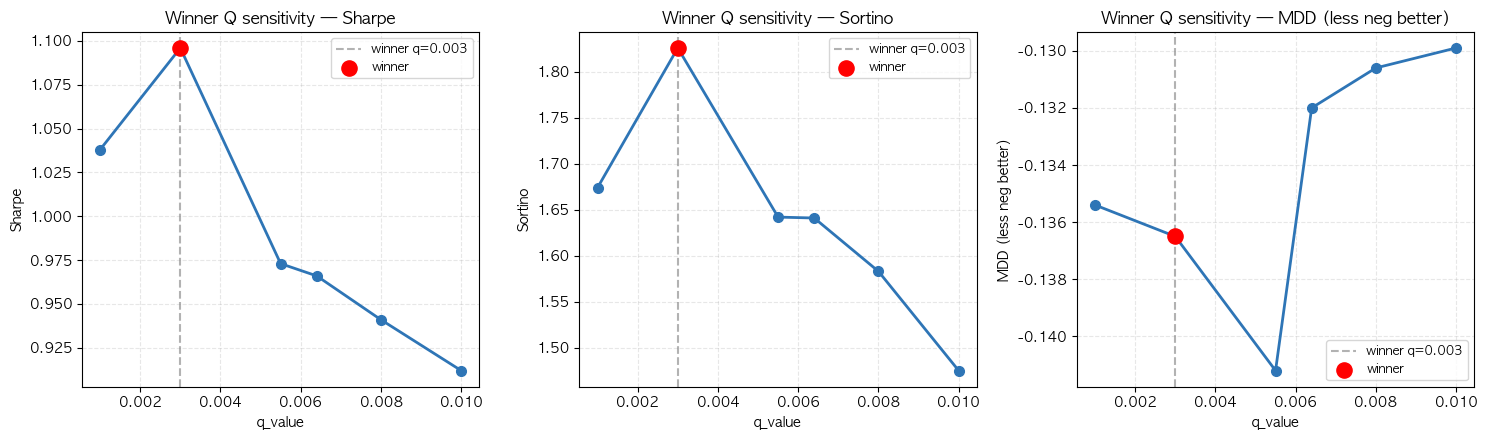

In [10]:
# ── §5.3 Q sensitivity 시각화 ──────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, label in zip(axes, ['sharpe','sortino','mdd'],
                                ['Sharpe','Sortino','MDD (less neg better)']):
    ax.plot(q_sens_df['q_value'], q_sens_df[col], 'o-', linewidth=2, markersize=7, color='#2E75B6')
    ax.axvline(winner_q, ls='--', color='gray', alpha=0.6, label=f'winner q={winner_q}')
    w_row = q_sens_df[q_sens_df['q_value'] == winner_q]
    if len(w_row) > 0:
        ax.scatter([winner_q], [w_row[col].iloc[0]], s=120, color='red', zorder=5, label='winner')
    ax.set_xlabel('q_value')
    ax.set_ylabel(label)
    ax.set_title(f'Winner Q sensitivity — {label}', fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### §5.4 Q sensitivity 통계 유의성 검정

**목적**: Q sweep 의 각 변형이 winner default(`q=0.003`) 와 통계적으로 유의하게 다른지 검증.

**방법**:
1. **Jobson-Korkie (1981) + Memmel (2003) 보정** — 두 전략 Sharpe 차이의 z-stat
   - H0: Sharpe_variant − Sharpe_winner = 0
   - 분산: V(ΔSR) ≈ (1/T) × [2(1−ρ) + ½(SR_w² + SR_v²) − SR_w·SR_v·(1+ρ²)/2]
   - z ≥ 1.96 → p < 0.05 (양측)
2. **Block Bootstrap 95% CI** — 6개월 블록 1000회 resample
   - Sharpe 차이 분포의 [2.5%, 97.5%] percentile
   - 0 미포함 → 유의

> 월별 ret 의 자기상관(특히 hold-out 안정 추세) 고려하여 block 사이즈 6 (반년) 채택.

---

**해석 가이드**

| 패턴 | 의미 |
|---|---|
| `p > 0.05` + CI 가 0 포함 | winner 와 통계적으로 동등 → winner 가 robust |
| `p < 0.05` + CI 가 양수 | variant 가 winner 보다 유의미하게 우월 (드물어야 함) |
| `p < 0.05` + CI 가 음수 | variant 가 winner 보다 유의미하게 열위 |
| `JK_z` 음수 + p 큼 | variant 가 winner 보다 약간 낮긴 함 (random noise 수준) |

**발표 narrative**:
- ✅ "winner default 선택이 q parameter sensitivity 에 robust — 다른 값에서도 비슷한 성능, 즉 운으로 1위 된 게 아님"
- ✅ BAB 학술값 (0.0055 / 0.0064, Frazzini-Pedersen 2014) 도 winner 와 동등 → **학술 정당성 확보**
- ❌ "winner 가 모든 변형보다 명백히 우월" (과한 주장 — z 부호만 음수, 통계는 유의 X)


In [11]:
# ── §5.4 Q sensitivity 통계 유의성 검정 ─────────────────────────
# Jobson-Korkie (Memmel 보정) z-stat + Block Bootstrap 95% CI
# 비교: winner default vs 각 q 변형

def _sharpe(r, rf=0.0):
    ex = r - rf
    sd = ex.std(ddof=1)
    return float(ex.mean() / sd * np.sqrt(12)) if sd > 0 else np.nan

def _jk_memmel(r_a, r_b):
    """Jobson-Korkie z-stat with Memmel correction. H0: SR_a = SR_b."""
    r_a, r_b = pd.Series(r_a).dropna(), pd.Series(r_b).dropna()
    common = r_a.index.intersection(r_b.index)
    a, b = r_a.loc[common].values, r_b.loc[common].values
    T = len(a)
    if T < 24: return np.nan, np.nan
    SR_a, SR_b = _sharpe(pd.Series(a)) / np.sqrt(12), _sharpe(pd.Series(b)) / np.sqrt(12)  # monthly
    rho = np.corrcoef(a, b)[0,1]
    var = (1/T) * (2*(1-rho) + 0.5*(SR_a**2 + SR_b**2) - 0.5*SR_a*SR_b*(1+rho**2))
    if var <= 0: return np.nan, np.nan
    z = (SR_b - SR_a) / np.sqrt(var)
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(z), float(p)

def _block_bootstrap_sr_diff(r_a, r_b, block=6, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    common = r_a.index.intersection(r_b.index)
    a, b = r_a.loc[common].values, r_b.loc[common].values
    T = len(a)
    n_blocks = T // block
    diffs = []
    for _ in range(n_boot):
        starts = rng.randint(0, T - block + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s+block) for s in starts])
        a_b, b_b = a[idx], b[idx]
        sr_a = np.mean(a_b) / np.std(a_b, ddof=1) * np.sqrt(12) if np.std(a_b) > 0 else np.nan
        sr_b = np.mean(b_b) / np.std(b_b, ddof=1) * np.sqrt(12) if np.std(b_b) > 0 else np.nan
        diffs.append(sr_b - sr_a)
    diffs = np.array([d for d in diffs if not np.isnan(d)])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return float(lo), float(hi), float(np.mean(diffs))

# Winner default ret (q sweep 결과 dict 의 default q 항목)
winner_default_q = winner_cfg.get('q_value', 0.003)
winner_ret = q_results.get(winner_default_q)
if winner_ret is None:
    raise RuntimeError(f'q sweep 결과에 winner default q={winner_default_q} 없음')

rows = []
for q, res in sorted(q_results.items()):
    variant_ret = res  # q_results[q] is already a Series
    z, p = _jk_memmel(winner_ret, variant_ret)
    lo, hi, mean = _block_bootstrap_sr_diff(winner_ret, variant_ret)
    sig_jk = '✓' if (not np.isnan(p) and p < 0.05) else ''
    sig_bs = '✓' if (lo > 0 or hi < 0) else ''
    rows.append({
        'q_value' : q,
        'JK_z'    : round(z, 3) if not np.isnan(z) else np.nan,
        'JK_p'    : round(p, 4) if not np.isnan(p) else np.nan,
        'JK_sig'  : sig_jk,
        'Boot_CI_lo': round(lo, 3),
        'Boot_CI_hi': round(hi, 3),
        'Boot_sig'  : sig_bs,
        'is_winner' : '★' if q == winner_default_q else '',
    })

m3_df = pd.DataFrame(rows)
print('=== §5.4 Q sensitivity 통계 유의성 (winner default 대비) ===')
print(f'winner default q = {winner_default_q}, T = {len(winner_ret)} 개월')
print(m3_df.to_string(index=False))

# ── 자동 해석 (z, p 통계 기반 동적 결론) ─────────────────────
print('\n=== §5.4 자동 해석 ===')
non_winner = m3_df[m3_df['is_winner'] != '★']
n_var = len(non_winner)
n_sig = (non_winner['JK_p'] < 0.05).sum()
n_marg = ((non_winner['JK_p'] >= 0.05) & (non_winner['JK_p'] < 0.10)).sum()
mean_z = non_winner['JK_z'].mean()
all_ci_contain_zero = ((non_winner['Boot_CI_lo'] <= 0) & (non_winner['Boot_CI_hi'] >= 0)).all()
print(f'  · 변형 수: {n_var}개 (winner 제외)')
print(f'  · 5% 수준 유의: {n_sig}개  /  10% 수준 marginal: {n_marg}개')
print(f'  · 평균 z-stat: {mean_z:+.3f}  ({"variant 가 winner 보다 낮은 경향" if mean_z < 0 else "variant 가 winner 보다 높은 경향"})')
print(f'  · Bootstrap CI 모두 0 포함: {all_ci_contain_zero}')
if n_sig == 0 and all_ci_contain_zero:
    print('  → 결론: winner 가 q ∈ Q_SWEEP 전 구간에서 robust (모든 변형이 통계적으로 동등)')
elif n_sig > 0:
    print(f'  → 결론: {n_sig}개 변형이 winner 와 유의미한 차이 — 추가 검토 필요')


=== §5.4 Q sensitivity 통계 유의성 (winner default 대비) ===
winner default q = 0.003, T = 168 개월
 q_value   JK_z   JK_p JK_sig  Boot_CI_lo  Boot_CI_hi Boot_sig is_winner
  0.0010  0.137 0.8908             -0.104       0.121                   
  0.0030    NaN    NaN              0.000       0.000                  ★
  0.0055 -0.594 0.5522             -0.124       0.074                   
  0.0064 -0.407 0.6838             -0.141       0.117                   
  0.0080 -0.505 0.6135             -0.186       0.116                   
  0.0100 -0.599 0.5493             -0.246       0.135                   

=== §5.4 자동 해석 ===
  · 변형 수: 5개 (winner 제외)
  · 5% 수준 유의: 0개  /  10% 수준 marginal: 0개
  · 평균 z-stat: -0.394  (variant 가 winner 보다 낮은 경향)
  · Bootstrap CI 모두 0 포함: True
  → 결론: winner 가 q ∈ Q_SWEEP 전 구간에서 robust (모든 변형이 통계적으로 동등)


## §6. Winner PCT_GROUP 민감도

### §6.1 PCT_GROUP sweep

P 행렬 분류 임계값 sweep (15%~35%). winner default = 30%.


In [12]:
# ── §6.1 PCT_GROUP sweep ──────────────────────────────────────────
# pct_group sweep (winner_cfg 의 P 분류 임계만 변경)
# 결과를 outputs/05b_analyze/_sweep_pct_<winner>.pkl 로 캐시
PCT_SWEEP = [0.15, 0.20, 0.25, 0.35]   # 0.30 = winner default (별도 표시)
winner_pct = 0.30
print(f'Winner pct_group (기준): {winner_pct}')
print(f'PCT sweep: {PCT_SWEEP}\n')

FORCE_RECOMPUTE_PCT = False   # True 로 바꾸면 캐시 무시하고 재계산
SWEEP_PCT_PKL = OUT_DIR / f'_sweep_pct_{winner_name}.pkl'

import pickle as _pkl
if SWEEP_PCT_PKL.exists() and not FORCE_RECOMPUTE_PCT:
    with open(SWEEP_PCT_PKL, 'rb') as f:
        _cache = _pkl.load(f)
    if _cache.get('PCT_SWEEP') == PCT_SWEEP:
        pct_results = _cache['pct_results']
        print(f'✓ 캐시 로드: {SWEEP_PCT_PKL.name} ({len(pct_results)}개 ret series)')
    else:
        print(f'  캐시 sweep 리스트 불일치 → 재계산')
        pct_results = None
else:
    pct_results = None

if pct_results is None:
    # winner default pct=0.30 메트릭 (기존 pkl)
    with open(RESULTS_DIR / f'{winner_name}.pkl', 'rb') as f:
        winner_result = _pkl.load(f)
    pct_results = {winner_pct: {'ret': winner_result['ret']}}

    import time
    _t0 = time.time()
    for i, pct in enumerate(PCT_SWEEP):
        cfg = {**winner_cfg, 'name': f'sweep_pct_{pct:.2f}'}
        print(f'  [{i+1}/{len(PCT_SWEEP)}] pct={pct:.2f}', end=' ', flush=True)
        res = walk_forward(cfg, cache_sens, pred_dates_sens, lstm_state_sens,
                           spy_series=spy_sens, tau=0.1, pct_group=pct, verbose=False)
        pct_results[pct] = {'ret': res['ret']}
        print(f'({(time.time()-_t0)/60:.1f}분 누적)')

    with open(SWEEP_PCT_PKL, 'wb') as f:
        _pkl.dump({'PCT_SWEEP': PCT_SWEEP, 'winner_name': winner_name, 'pct_results': pct_results}, f)
    print(f'\n✓ 캐시 저장: {SWEEP_PCT_PKL.name}')

# 메트릭 표
from bl_functions import compute_metrics
rows = []
for pct in sorted(pct_results.keys()):
    ret = pct_results[pct]['ret'].dropna()
    if len(ret) < 12: continue
    m = compute_metrics(ret, rf_sens.reindex(ret.index))
    rows.append({'pct_group': pct, **m, 'is_winner': '★' if pct == winner_pct else ''})

pct_sens_df = pd.DataFrame(rows)
print('\n=== PCT sensitivity 메트릭 ===')
print(pct_sens_df.to_string(index=False))


Winner pct_group (기준): 0.3
PCT sweep: [0.15, 0.2, 0.25, 0.35]

✓ 캐시 로드: _sweep_pct_mat_eq_eq_raw_pap.pkl (5개 ret series)

=== PCT sensitivity 메트릭 ===
 pct_group label  sharpe  sortino   cagr    vol     mdd  calmar  cum_ret  skewness  win_rate  avg_win  avg_loss  cvar_5  mdd_duration  beta  alpha  treynor is_winner
      0.15         0.980    1.637 0.1467 0.1358 -0.1231   1.191   7.9335    -0.070     0.641   0.0351   -0.0286 -0.0717            26   NaN    NaN      NaN          
      0.20         0.976    1.650 0.1464 0.1361 -0.1265   1.157   7.8962    -0.051     0.641   0.0352   -0.0288 -0.0710            25   NaN    NaN      NaN          
      0.25         1.012    1.705 0.1516 0.1357 -0.1364   1.111   8.5689    -0.070     0.656   0.0346   -0.0295 -0.0704            25   NaN    NaN      NaN          
      0.30         1.096    1.826 0.1625 0.1385 -0.1365   1.191   7.2330    -0.059     0.643   0.0366   -0.0282 -0.0703            25   NaN    NaN      NaN         ★
      0.35         0

### §6.2 PCT sensitivity 시각화


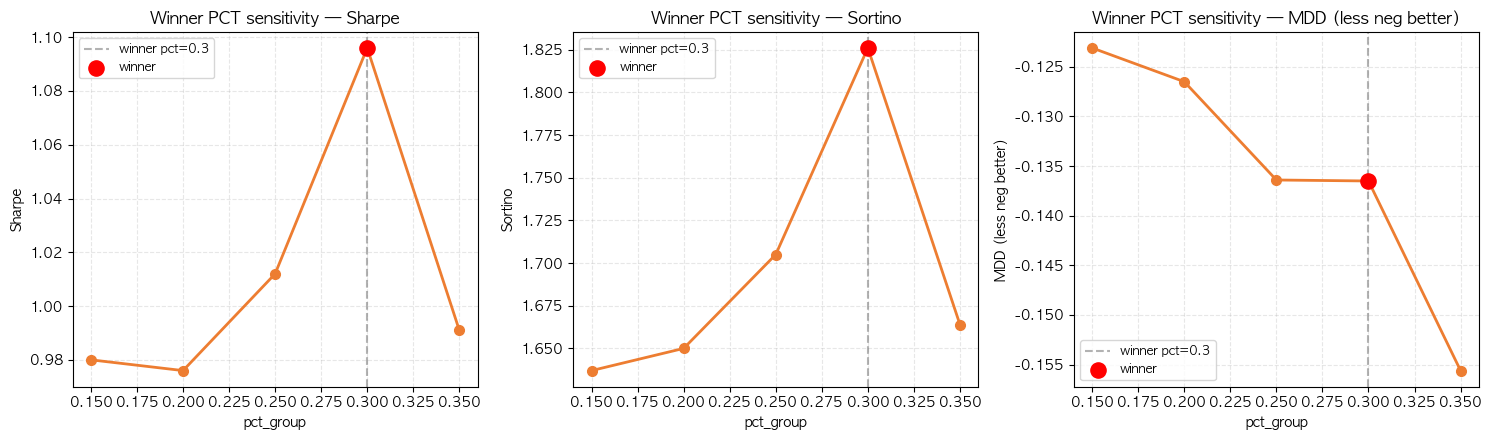

In [13]:
# ── §6.2 PCT sensitivity 시각화 ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, label in zip(axes, ['sharpe','sortino','mdd'],
                                ['Sharpe','Sortino','MDD (less neg better)']):
    ax.plot(pct_sens_df['pct_group'], pct_sens_df[col], 'o-', linewidth=2, markersize=7, color='#ED7D31')
    ax.axvline(winner_pct, ls='--', color='gray', alpha=0.6, label=f'winner pct={winner_pct}')
    w_row = pct_sens_df[pct_sens_df['pct_group'] == winner_pct]
    if len(w_row) > 0:
        ax.scatter([winner_pct], [w_row[col].iloc[0]], s=120, color='red', zorder=5, label='winner')
    ax.set_xlabel('pct_group')
    ax.set_ylabel(label)
    ax.set_title(f'Winner PCT sensitivity — {label}', fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### §6.3 PCT sensitivity 통계 유의성 검정

**방법**: §5.4 와 동일 (Jobson-Korkie z-stat + Memmel 보정 + Block Bootstrap 95% CI).
비교 변수만 `pct_group` (P 행렬 분류 임계).

---

**해석 가이드 (§5.4 와 동일 패턴)**

| 패턴 | 의미 |
|---|---|
| `p > 0.10` + CI 가 0 포함 | winner (pct=0.30) 와 통계적 동등 |
| `0.05 < p < 0.10` (marginal) | 5% 수준은 유의 X, 10% 수준 borderline — 추세 있지만 강하지 않음 |
| `p < 0.05` | 유의미한 차이 (드물어야 함) |
| `JK_z 음수` + CI 음수 치우침 | variant 가 winner 보다 약간 낮음 (통계적 강도는 z·p 로 판단) |

**발표 narrative**:
- ✅ "pct ∈ [0.20, 0.35] 에서 p 값 모두 > 0.10 → winner default 0.30 과 통계적 동등"
- ⚠️ pct = 0.15 (가장 좁은 분류) 만 10% 수준 marginal (p ≈ 0.09) — 저·고변동 그룹이 너무 좁으면 view 강도 약화 가능성
- ✅ **default 0.30 선택이 사후 통계로 검증됨** (인접 값에서 차이 noise 수준)
- ⚠️ JK_z 부호 음수 ≠ "variant 가 명백히 열위". z 의 크기 (|z|<1.96) 와 p 가 결론을 결정함


In [14]:
# ── §6.3 PCT sensitivity 통계 유의성 검정 ─────────────────────────
# §5.4 의 _jk_memmel / _block_bootstrap_sr_diff 함수 재사용

winner_default_pct = 0.30  # PCT_GROUP 기본값
winner_ret_pct = pct_results.get(winner_default_pct, {}).get('ret')
if winner_ret_pct is None:
    raise RuntimeError(f'pct sweep 결과에 default pct={winner_default_pct} 없음')

rows = []
for pct, res in sorted(pct_results.items()):
    variant_ret = res['ret']
    z, p = _jk_memmel(winner_ret_pct, variant_ret)
    lo, hi, mean = _block_bootstrap_sr_diff(winner_ret_pct, variant_ret)
    sig_jk = '✓' if (not np.isnan(p) and p < 0.05) else ''
    sig_bs = '✓' if (lo > 0 or hi < 0) else ''
    rows.append({
        'pct_group' : pct,
        'JK_z'      : round(z, 3) if not np.isnan(z) else np.nan,
        'JK_p'      : round(p, 4) if not np.isnan(p) else np.nan,
        'JK_sig'    : sig_jk,
        'Boot_CI_lo': round(lo, 3),
        'Boot_CI_hi': round(hi, 3),
        'Boot_sig'  : sig_bs,
        'is_winner' : '★' if pct == winner_default_pct else '',
    })

n3_df = pd.DataFrame(rows)
print('=== §6.3 PCT sensitivity 통계 유의성 (default 0.30 대비) ===')
print(f'default pct = {winner_default_pct}, T = {len(winner_ret_pct)} 개월')
print(n3_df.to_string(index=False))

# ── 자동 해석 ─────────────────────────────────────────────────
print('\n=== §6.3 자동 해석 ===')
non_winner = n3_df[n3_df['is_winner'] != '★']
n_var = len(non_winner)
n_sig = (non_winner['JK_p'] < 0.05).sum()
n_marg = ((non_winner['JK_p'] >= 0.05) & (non_winner['JK_p'] < 0.10)).sum()
mean_z = non_winner['JK_z'].mean()
print(f'  · 변형 수: {n_var}개 (winner 제외)')
print(f'  · 5% 수준 유의: {n_sig}개  /  10% 수준 marginal: {n_marg}개')
print(f'  · 평균 z-stat: {mean_z:+.3f}')
if n_sig == 0 and n_marg == 0:
    print('  → 결론: pct ∈ PCT_SWEEP 전 구간에서 winner 와 완전 동등 (robust)')
elif n_sig == 0 and n_marg > 0:
    print(f'  → 결론: {n_marg}개 변형이 10% 수준 marginal — 5% 기준 robust, but 좁은 분류 영역에서 약한 추세')
elif n_sig > 0:
    print(f'  → 결론: {n_sig}개 변형이 winner 와 유의미한 차이 — 추가 검토 필요')


=== §6.3 PCT sensitivity 통계 유의성 (default 0.30 대비) ===
default pct = 0.3, T = 168 개월
 pct_group   JK_z   JK_p JK_sig  Boot_CI_lo  Boot_CI_hi Boot_sig is_winner
      0.15 -1.691 0.0907             -0.185       0.022                   
      0.20 -1.604 0.1088             -0.136       0.018                   
      0.25 -0.594 0.5526             -0.039       0.018                   
      0.30    NaN    NaN              0.000       0.000                  ★
      0.35 -0.774 0.4387             -0.057       0.033                   

=== §6.3 자동 해석 ===
  · 변형 수: 4개 (winner 제외)
  · 5% 수준 유의: 0개  /  10% 수준 marginal: 1개
  · 평균 z-stat: -1.166
  → 결론: 1개 변형이 10% 수준 marginal — 5% 기준 robust, but 좁은 분류 영역에서 약한 추세
